# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.portfolio as portfolio_module
import model.analysis.profit as profit_analysis
import model.data.loader as loader

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(portfolio_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality = assumptions_module.load_mortality_table(
    "../data/mortality_tables/basic_mortality_table.csv"
)

interest = assumptions_module.FlatYieldCurve(
    interest_rate=0.03
)

lapse_table = assumptions_module.load_lapse_table(
    "../data/lapse_rates.csv"
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest,
    lapse=lapse_table
)

# Portfolio Setup

In [5]:
portfolio = loader.load_portfolio_csv(
    "../data/sample_portfolio.csv"
)

portfolio

=== PORTFOLIO SUMMARY ===
PV Premiums : 1,279,525,855.55
PV Claims   : 2,433,376,253.84
Net Value   : -1,153,850,398.29

=== EMERGENCE PREVIEW ===


,t,expected_premium,expected_claim,expected_lapse,pv_net,cum_profit
0,0,1.000128e+08,9.214018e+07,818.420000,7.872613e+06,7.872613e+06
1,1,9.744595e+07,9.815546e+07,492.452720,-6.888463e+05,7.183766e+06
2,2,9.553007e+07,1.052312e+08,456.838276,-9.144207e+06,-1.960441e+06
3,3,9.362543e+07,1.125275e+08,423.397241,-1.729811e+07,-1.925855e+07
4,4,9.172481e+07,1.199711e+08,392.005808,-2.509649e+07,-4.435504e+07
5,5,8.809642e+07,1.231237e+08,240.535464,-3.021481e+07,-7.456985e+07
6,6,8.303547e+07,1.298914e+08,219.709824,-3.924108e+07,-1.138109e+08
7,7,7.914086e+07,1.370573e+08,201.659657,-4.709135e+07,-1.609023e+08
8,8,7.427208e+07,1.424169e+08,189.832684,-5.379414e+07,-2.146964e+08
9,9,7.157192e+07,1.386303e+08,175.261465,-5.139467e+07,-2.660911e+08


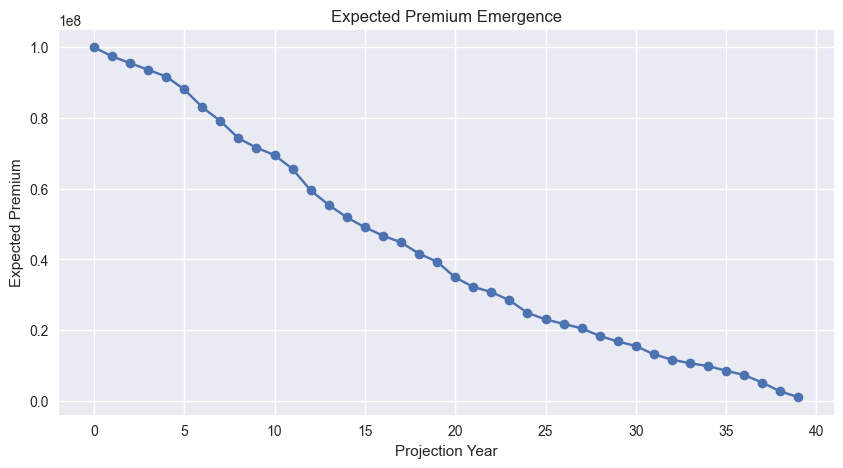

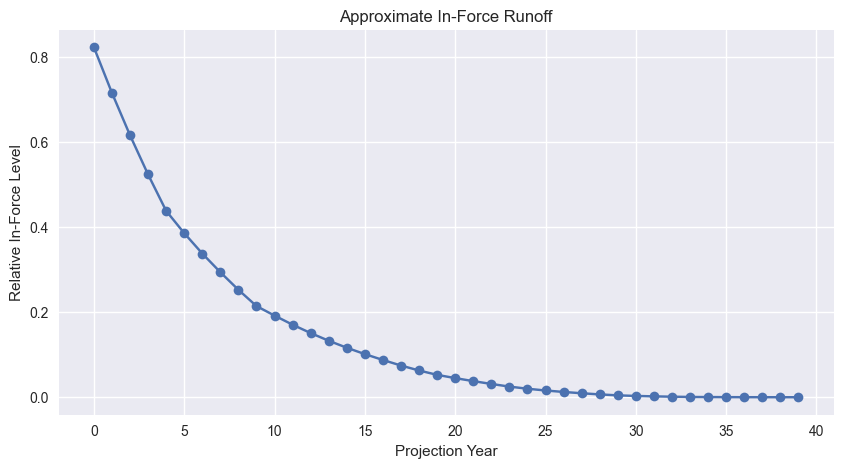

In [6]:
# Run portfolio valuation
result = portfolio.value(
    assumptions,
    return_breakdown=True
)

# Build emergence dataframe
df = profit_analysis.build_profit_dataframe(result)

# =========================
# Summary metrics
# =========================

print("=== PORTFOLIO SUMMARY ===")
print(f"PV Premiums : {result.pv_premiums:,.2f}")
print(f"PV Claims   : {result.pv_claims:,.2f}")
print(f"Net Value   : {result.net_value:,.2f}")
print()

# =========================
# Emergence preview
# =========================

print("=== EMERGENCE PREVIEW ===")

display_cols = [
    "t",
    "expected_premium",
    "expected_claim",
    "expected_lapse",
    "pv_net",
    "cum_profit"
]

display(df[display_cols].head(10))

# =========================
# Premium emergence chart
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    df["t"],
    df["expected_premium"],
    marker="o"
)

plt.title("Expected Premium Emergence")
plt.xlabel("Projection Year")
plt.ylabel("Expected Premium")

plt.grid(True)

plt.show()

# =========================
# In-force runoff chart
# =========================

plt.figure(figsize=(10, 5))

if df["expected_lapse"].sum() > 0:

    runoff = 1 - (
        df["expected_lapse"].cumsum()
        / df["expected_lapse"].sum()
    )

else:

    runoff = [1.0] * len(df)

plt.plot(
    df["t"],
    runoff,
    marker="o"
)

plt.title("Approximate In-Force Runoff")
plt.xlabel("Projection Year")
plt.ylabel("Relative In-Force Level")

plt.grid(True)

plt.show()

# Portfolio Inspection

In [7]:
len(portfolio.policies)

250

In [8]:
portfolio.policies[0]

Policy(age=60, term=12, sum_assured=25000.0, premium=291.0, gender=M, smoker_status=Smoker, product_type=Endowment, weight=63)

# Portfolio Valuation

In [9]:
portfolio_result = portfolio.value(
    assumptions,
    return_breakdown=True
)

portfolio_result

PortfolioResult(policies=250, net_value=-1153850398.29)

# Portfolio DataFrame

In [10]:
portfolio_df = profit_analysis.build_profit_dataframe(
    portfolio_result
)

portfolio_df.head()

,t,age,discount_factor,lapse_rate,expected_premium,expected_claim,expected_lapse,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow
0,0,60,1.000000,0.0,1.000128e+08,9.214018e+07,818.420000,7.872613e+06,1.000128e+08,9.214018e+07,7.872613e+06,7.872613e+06,7.872613e+06
1,1,61,0.970874,0.0,9.744595e+07,9.815546e+07,492.452720,-7.095117e+05,9.460772e+07,9.529656e+07,-6.888463e+05,7.183766e+06,7.163101e+06
2,2,62,0.942596,0.0,9.553007e+07,1.052312e+08,456.838276,-9.701090e+06,9.004625e+07,9.919046e+07,-9.144207e+06,-1.960441e+06,-2.537989e+06
3,3,63,0.915142,0.0,9.362543e+07,1.125275e+08,423.397241,-1.890211e+07,8.568053e+07,1.029786e+08,-1.729811e+07,-1.925855e+07,-2.144010e+07
4,4,64,0.888487,0.0,9.172481e+07,1.199711e+08,392.005808,-2.824632e+07,8.149631e+07,1.065928e+08,-2.509649e+07,-4.435504e+07,-4.968642e+07


# Profit Signature

In [11]:
portfolio_signature = profit_analysis.add_profit_signature(
    portfolio_df
)

portfolio_signature.head()

,t,age,discount_factor,lapse_rate,expected_premium,expected_claim,expected_lapse,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow,profit_pct
0,0,60,1.000000,0.0,1.000128e+08,9.214018e+07,818.420000,7.872613e+06,1.000128e+08,9.214018e+07,7.872613e+06,7.872613e+06,7.872613e+06,-0.006823
1,1,61,0.970874,0.0,9.744595e+07,9.815546e+07,492.452720,-7.095117e+05,9.460772e+07,9.529656e+07,-6.888463e+05,7.183766e+06,7.163101e+06,0.000597
2,2,62,0.942596,0.0,9.553007e+07,1.052312e+08,456.838276,-9.701090e+06,9.004625e+07,9.919046e+07,-9.144207e+06,-1.960441e+06,-2.537989e+06,0.007925
3,3,63,0.915142,0.0,9.362543e+07,1.125275e+08,423.397241,-1.890211e+07,8.568053e+07,1.029786e+08,-1.729811e+07,-1.925855e+07,-2.144010e+07,0.014992
4,4,64,0.888487,0.0,9.172481e+07,1.199711e+08,392.005808,-2.824632e+07,8.149631e+07,1.065928e+08,-2.509649e+07,-4.435504e+07,-4.968642e+07,0.021750


# Summary Metrics

In [12]:
profit_analysis.summary_metrics(portfolio_df)

{'total_pv_profit': np.float64(-1153850398.290604),
 'total_cash_profit': np.float64(-1920676799.7100163),
 'peak_profit_year': np.int64(0)}

# Visualisations

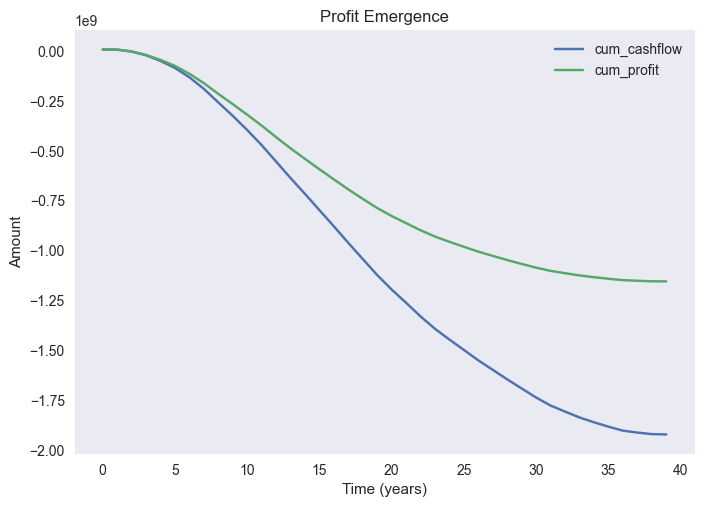

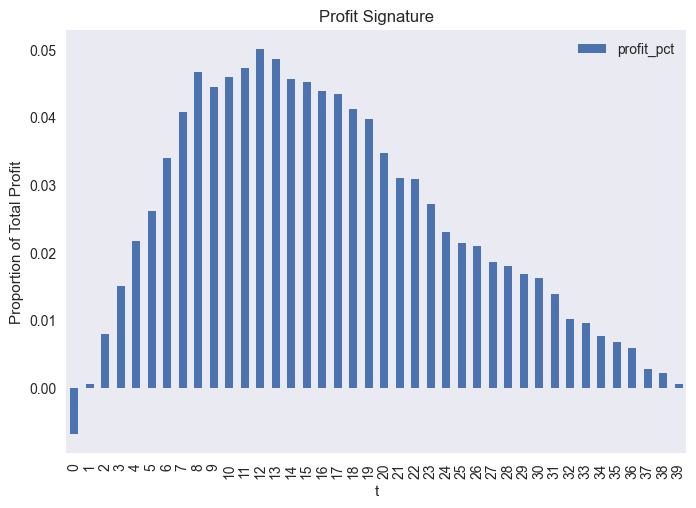

In [13]:
# Profit Emergence

portfolio_df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

portfolio_signature.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()